Raw data from the source.

✓ Dataset 1 (2018-2019): 916,765 rows
✓ Dataset 2 (2020-2025): 4,581,797 rows
✓ Total: 5,498,562 rows

✓ Combined: 5,498,562 rows
✓ Memory: 11018.92 MB

DATA SIZE
Rows: 5,498,562
Columns: 44
Shape: (5498562, 44)

PROPERTIES
Date range: 2018-01-01 to 2025-12-30
Geographic: Yes (borough data available)
Borough
BRONX            1526151
MANHATTAN        1448744
BROOKLYN         1368484
QUEENS           1032718
STATEN ISLAND     120422
Name: count, dtype: int64

Missing values: 59588268 total
Duplicates: 0

FUNDAMENTAL DISTRIBUTIONS


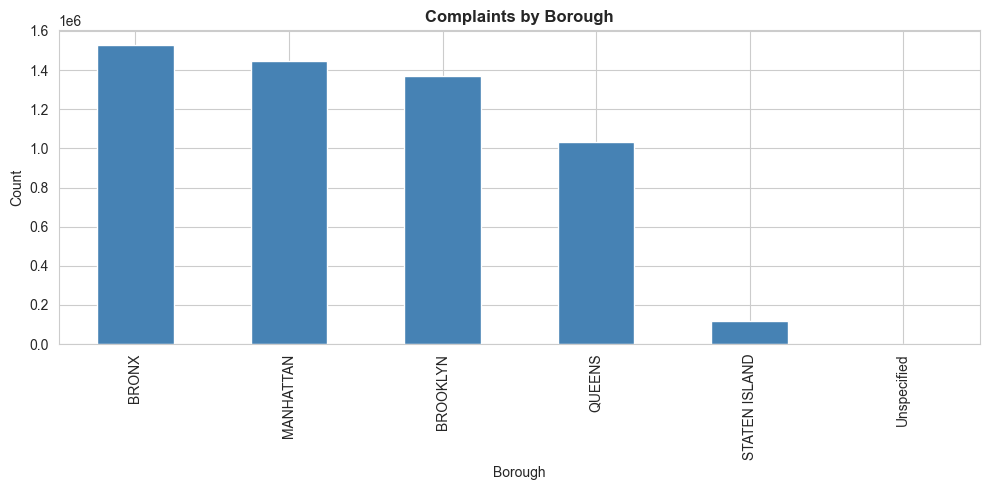

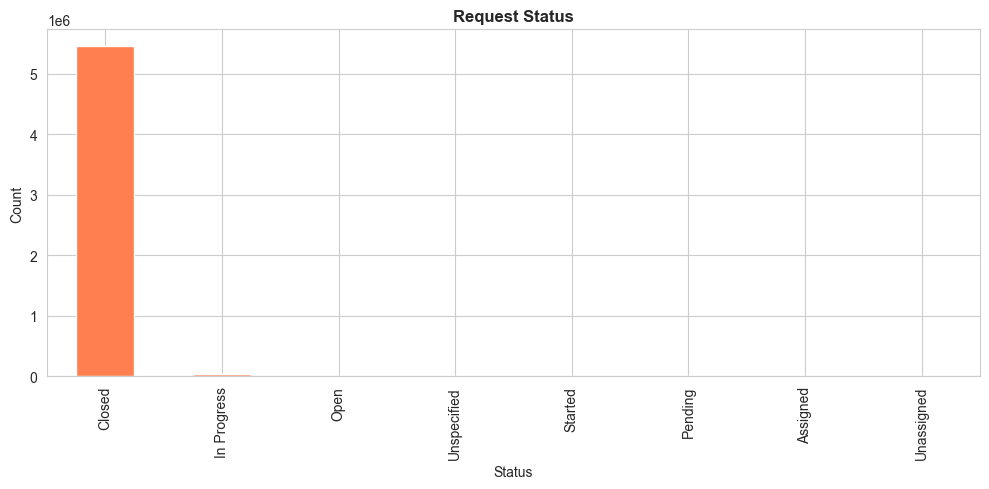

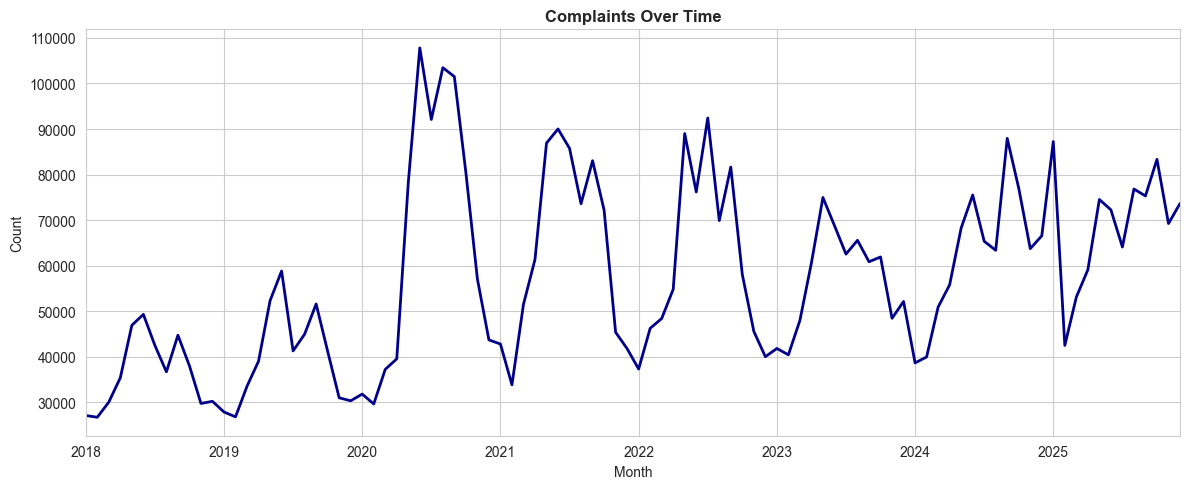

✓ Analysis complete


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load both CSVs from Downloads
home = os.path.expanduser("~")
file_path1 = os.path.join(home, "Downloads", "311_Service_Requests_from_2018_to_2019_20260413.csv")
file_path2 = os.path.join(home, "Downloads", "311_Service_Requests_from_2020_to_2025_20260413.csv")

df1 = pd.read_csv(file_path1)
df2 = pd.read_csv(file_path2)

print(f"✓ Dataset 1 (2018-2019): {len(df1):,} rows")
print(f"✓ Dataset 2 (2020-2025): {len(df2):,} rows")
print(f"✓ Total: {len(df1) + len(df2):,} rows\n")

# Combine both datasets
df = pd.concat([df1, df2], ignore_index=True)
print(f"✓ Combined: {len(df):,} rows")
print(f"✓ Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

# Data size
print("="*60)
print("DATA SIZE")
print("="*60)
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Shape: {df.shape}\n")

# Properties
print("="*60)
print("PROPERTIES")
print("="*60)

# Date range
date_cols = [col for col in df.columns if 'date' in col.lower()]
if date_cols:
    date_col = date_cols[0]
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    print(f"Date range: {df[date_col].min().date()} to {df[date_col].max().date()}")

# Geographic
borough_cols = [col for col in df.columns if 'borough' in col.lower()]
if borough_cols:
    print(f"Geographic: Yes (borough data available)")
    print(df[borough_cols[0]].value_counts().head())

# Missing data
print(f"\nMissing values: {df.isnull().sum().sum()} total")
print(f"Duplicates: {df.duplicated().sum()}\n")

# Fundamental distributions
print("="*60)
print("FUNDAMENTAL DISTRIBUTIONS")
print("="*60)

sns.set_style('whitegrid')

# Plot 1: Borough
if borough_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    df[borough_cols[0]].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Complaints by Borough', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

# Plot 2: Status
status_cols = [col for col in df.columns if 'status' in col.lower()]
if status_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    df[status_cols[0]].value_counts().plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Request Status', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

# Plot 3: Complaint types over time
if date_cols:
    complaints_per_month = df[date_col].dt.to_period('M').value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    complaints_per_month.plot(kind='line', ax=ax, color='darkblue', linewidth=2)
    ax.set_title('Complaints Over Time', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    ax.set_xlabel('Month')
    plt.tight_layout()
    plt.show()

print("✓ Analysis complete")

Removing unspecified boroughs

After removing Unspecified: 5,496,519 rows


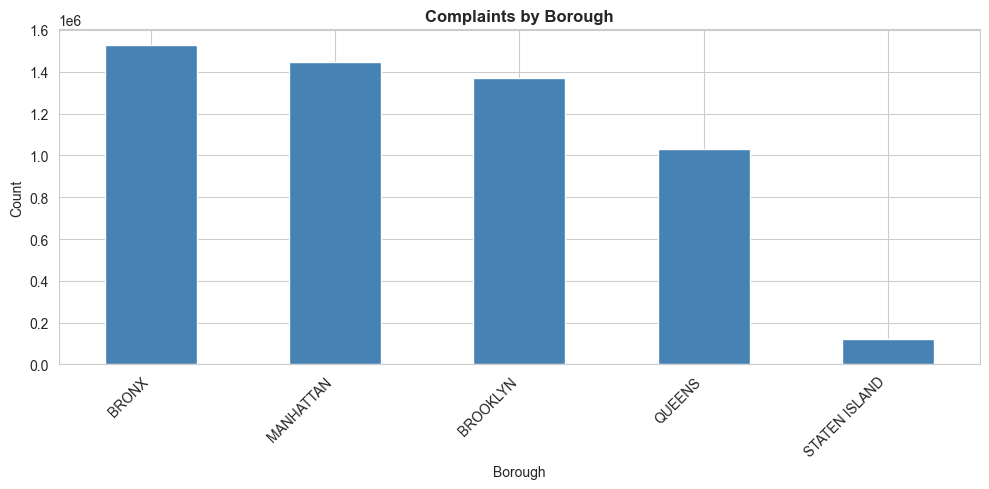

In [ ]:
# Remove unspecified boroughs
df_clean = df_clean[df_clean['Borough'] != 'Unspecified']
print(f"After removing Unspecified: {len(df_clean):,} rows")

# Plot 1: Borough
if borough_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    df[borough_cols[0]].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title('Complaints by Borough', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


In [54]:
df.describe()

,Unique Key,Created Date,Incident Zip,Council District,BBL,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude
count,5.498562e+06,5498562,5.495020e+06,5.472561e+06,4.998778e+06,0.0,0.0,0.0,0.0,0.0,0.0,5.467740e+06,5.467740e+06
mean,5.392487e+07,2022-05-13 20:02:16.107324160,1.070222e+04,2.094693e+01,2.448493e+09,NaN,NaN,NaN,NaN,NaN,NaN,4.076079e+01,-7.391882e+01
min,3.806531e+07,2018-01-01 00:04:05,0.000000e+00,1.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,4.049854e+01,-7.425495e+01
25%,4.721985e+07,2020-08-11 19:20:12.249999872,1.004000e+04,1.000000e+01,1.022160e+09,NaN,NaN,NaN,NaN,NaN,NaN,4.069164e+01,-7.395823e+01
50%,5.430688e+07,2022-05-28 22:55:42.500000,1.046600e+04,1.700000e+01,2.048330e+09,NaN,NaN,NaN,NaN,NaN,NaN,4.075598e+01,-7.392280e+01
75%,6.113280e+07,2024-05-12 03:55:35.500000,1.122500e+04,3.400000e+01,3.056600e+09,NaN,NaN,NaN,NaN,NaN,NaN,4.083712e+01,-7.387087e+01
max,6.734396e+07,2025-12-30 23:59:35,1.234500e+04,5.100000e+01,5.270001e+09,NaN,NaN,NaN,NaN,NaN,NaN,4.091346e+01,-7.370038e+01
std,8.150205e+06,NaN,5.405559e+02,1.371813e+01,1.134900e+09,NaN,NaN,NaN,NaN,NaN,NaN,8.627997e-02,6.583554e-02
